9600
 -----------------------------------------------------------------------
 ----------------------------  Results  --------------------------------
 MAX ENZYME ACTIVITY :  1.3384783037963077


<Figure size 700x500 with 0 Axes>

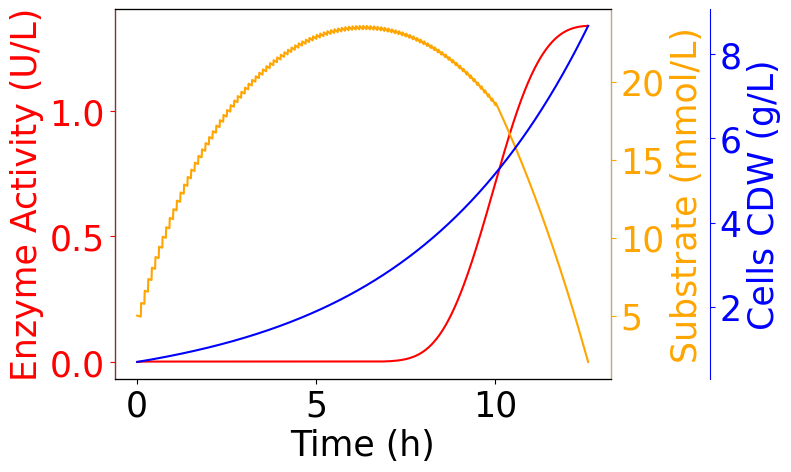

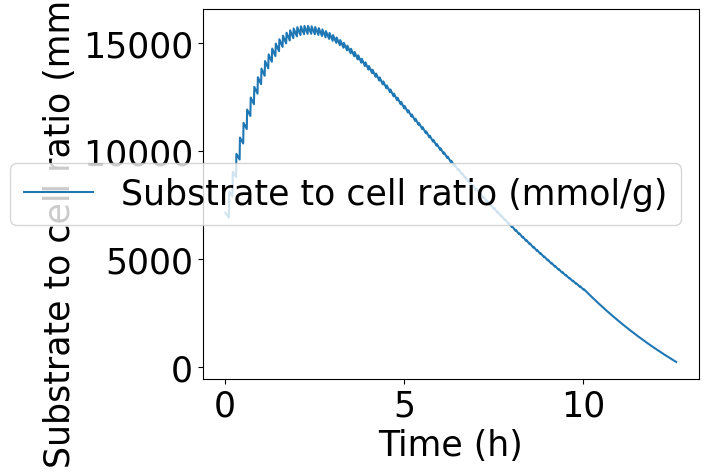

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os

# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
print(ns)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            substrate_action = 0.01
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.get_weibull_y_value(sub_cell_ratio, peak= config.OPT_SUB_CELL_RATIO*1e6)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
S_C_R = S_C_R * 1e6

max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)

'''
================================================================================================================================================
                                                    Plotting      
================================================================================================================================================
'''

print(" -----------------------------------------------------------------------")
print(" ----------------------------  Results  --------------------------------")
print(" MAX ENZYME ACTIVITY : ", max(D[:,2]))

import matplotlib.pyplot as plt
import os

# Set global font to Dejavu Sans
plt.rcParams["font.family"] = "sans-serif"

# First figure
plt.figure(figsize=(7, 5))
fig, ax1 = plt.subplots()

ax1.plot(tvec[0:i], E, color="red", label="Enzyme Activity U/L")
ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S*1e3, color="orange", label="Substrate mmol/L")
ax3 = ax1.twinx()
ax3.plot(tvec[0:i], X, color="blue", label="Cells CDW g/L")
ax3.spines['right'].set_position(('axes', 1.20))

# Set axis labels with increased fontsize
ax1.set_ylabel("Enzyme Activity (U/L)", color="red", fontsize=25)
ax1.set_xlabel("Time (h)", fontsize=25)
ax2.set_ylabel("Substrate (mmol/L)", color="orange", fontsize=25)
ax3.set_ylabel("Cells CDW (g/L)", color="blue", fontsize=25)

# Tick parameters with increased fontsize
ax1.tick_params(axis='y', colors="red", labelsize=25)
ax2.tick_params(axis='y', colors="orange", labelsize=25)
ax3.tick_params(axis='y', colors="blue", labelsize=25)
ax1.tick_params(axis='x', labelsize=25)

# Customize spines
ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")

# Save the figure as PDF
figure_path = os.path.join('figures','figure2','figure2a.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=600)

plt.show()

# Second figure
plt.figure()
plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mmol/g)")

# Set axis labels and legend fontsize
plt.xlabel("Time (h)", fontsize=25)
plt.ylabel("Substrate to cell ratio (mmol/g)", fontsize=25)
plt.tick_params(axis='both', labelsize=25)
plt.legend(fontsize=25)

plt.show()



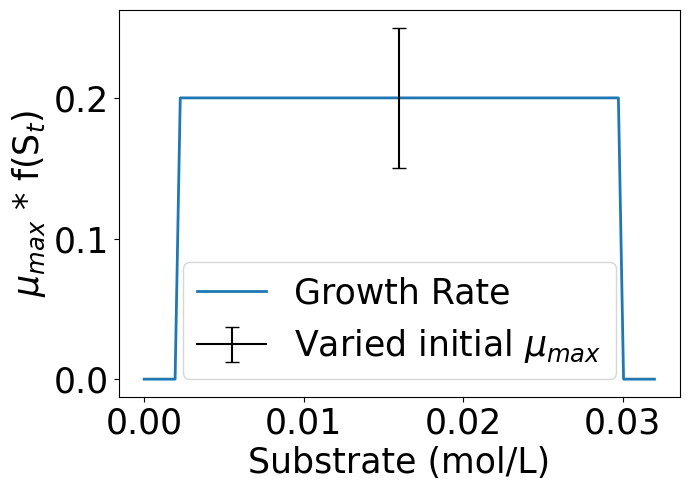

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import utils
import config
import os

# Generate substrate concentration values
s_conc = np.linspace(0, 0.032, 100)
rates = []

# Calculate rates based on substrate concentrations
for S in s_conc:
    rates.append(utils.cell_growth_rate(S))

# Define the center, max, and min for the error bar
center = 0.2  # Mean value
max_val = 0.25  # Maximum value
min_val = 0.15  # Minimum value

# Calculate the error (distance from center to max or min)
error = [[center - min_val], [max_val - center]]

# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"
# Plot the rates
plt.figure(figsize=(7, 5))
plt.plot(s_conc, rates, label="Growth Rate", linewidth=2)

# Customize axes labels with fontsize=15
plt.xlabel("Substrate (mol/L)", fontsize=25)
plt.ylabel(r"$\mu_{max}$ * f(S$_t$)", fontsize=25)

# Add the error bar
plt.errorbar(
    x=[0.016],  # Place the error bar at a specific x-coordinate (e.g., 0.016)
    y=[center],  # Center of the error bar
    yerr=error,  # Error range (min and max)
    fmt='',  # Marker style
    color='black',  # Error bar color
    label=r"Varied initial $\mu_{max}$",
    capsize=5,  # Add caps to the error bar
    linewidth=1.5
)

# Add legend with increased fontsize
plt.legend(fontsize=25)

# Customize tick parameters with fontsize=25
plt.tick_params(axis='both', which='major', labelsize=25)

# Save the figure as PDF
figure_path = os.path.join('figures','figure2','figure2c.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=600)
# Adjust layout and display the plot
plt.tight_layout()
plt.show()



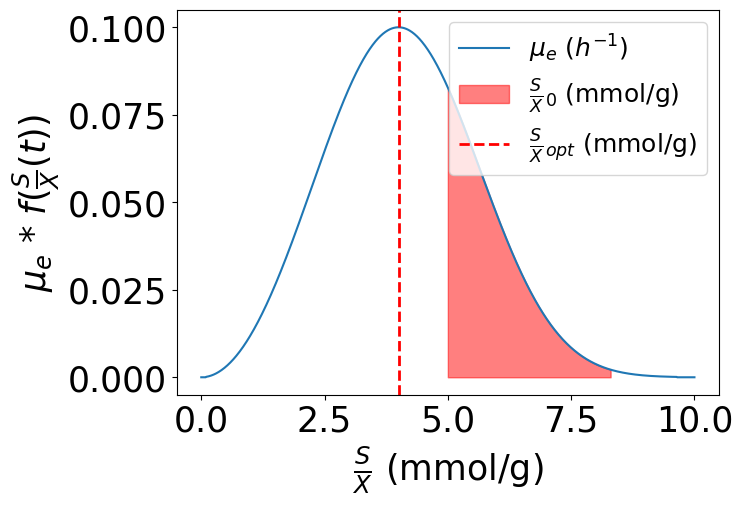

In [12]:
import numpy as np
from scipy.stats import weibull_min
import matplotlib.pyplot as plt

def get_weibull_y_value(input_value, k=3, peak=4, max_x=10, num_points=1000):
    # Compute the scale parameter (lambda) based on the shape parameter
    lambda_ = peak / ((k - 1) / k)**(1 / k)

    # Generate x values and Weibull PDF
    x = np.linspace(0, max_x, num_points)
    pdf = weibull_min.pdf(x, k, scale=lambda_)

    # Normalize the PDF to range from 0 to 1
    pdf = pdf / np.max(pdf)

    # Find the corresponding Y value using interpolation
    y_value = np.interp(input_value, x, pdf)

    if y_value <= 0.001:
        y_value = 0

    return y_value

# Generate x and y values
x = np.linspace(0, 10, 1000)
y = [get_weibull_y_value(i, peak=4)*0.1 for i in x]

# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"

plt.figure(figsize=(7,5))
# Plot the curve
plt.plot(x, y, label=r'$\mu_e$ ($h^{-1}$)')

# Shade the region under the curve from x = 6000 to x = 8000
x_shaded = np.linspace(5, 8.3, 100)
y_shaded = [get_weibull_y_value(i, peak=4)*0.1 for i in x_shaded]
plt.fill_between(x_shaded, y_shaded, color='red', alpha=0.5, label=r'$\frac{S}{X}_0$ (mmol/g)')

# Add labels and vertical line
plt.xlabel(r'$\frac{S}{X}$ (mmol/g)', fontsize=25)
plt.ylabel(r'$\mu_e$ * $ f (\frac{S}{X}(t))$', fontsize=25)
plt.axvline(x=4, color='r', linestyle='--', linewidth=2, label=r'$\frac{S}{X}_{opt}$ (mmol/g)')

# Customize tick parameters with fontsize=25
plt.tick_params(axis='both', which='major', labelsize=25)
# Add legend and show plot
plt.legend(fontsize=18)
figure_path = os.path.join('figures','figure2','figure2d.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=600)
plt.show()

